In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the data:
#from google.colab import files
#uploaded = files.upload()

In [5]:
iris_dataset = pd.read_csv("iris.csv", sep=',')
display(iris_dataset)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


# Explore the data

In [8]:
# Explore the data
print("Keys of iris_dataset:\n", iris_dataset.keys())
# What are the target names?
print("Target names:\n", np.unique(iris_dataset['Species']))
# Feature names:
print("Feature names:\n", iris_dataset.keys()[0:4])
# Type of data:
print("Type of data:\n", type(iris_dataset['SepalLengthCm'][:]))
# 

Keys of iris_dataset:
 Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
Target names:
 ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Feature names:
 Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm'], dtype='object')
Type of data:
 <class 'pandas.core.series.Series'>


# Measuring performance

In [14]:
# Convert string target vector to integer
y=pd.factorize(iris_dataset['Species'])
#display(y)
X = iris_dataset.loc[:,'SepalLengthCm':'PetalWidthCm']
#display(y[1][2])
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y[0], random_state=0)
display(X_test)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
114,5.8,2.8,5.1,2.4
62,6.0,2.2,4.0,1.0
33,5.5,4.2,1.4,0.2
107,7.3,2.9,6.3,1.8
7,5.0,3.4,1.5,0.2
100,6.3,3.3,6.0,2.5
40,5.0,3.5,1.3,0.3
86,6.7,3.1,4.7,1.5
76,6.8,2.8,4.8,1.4
71,6.1,2.8,4.0,1.3


In [15]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (112, 4)
y_train shape: (112,)


In [10]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (38, 4)
y_test shape: (38,)


# Data exploration

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')


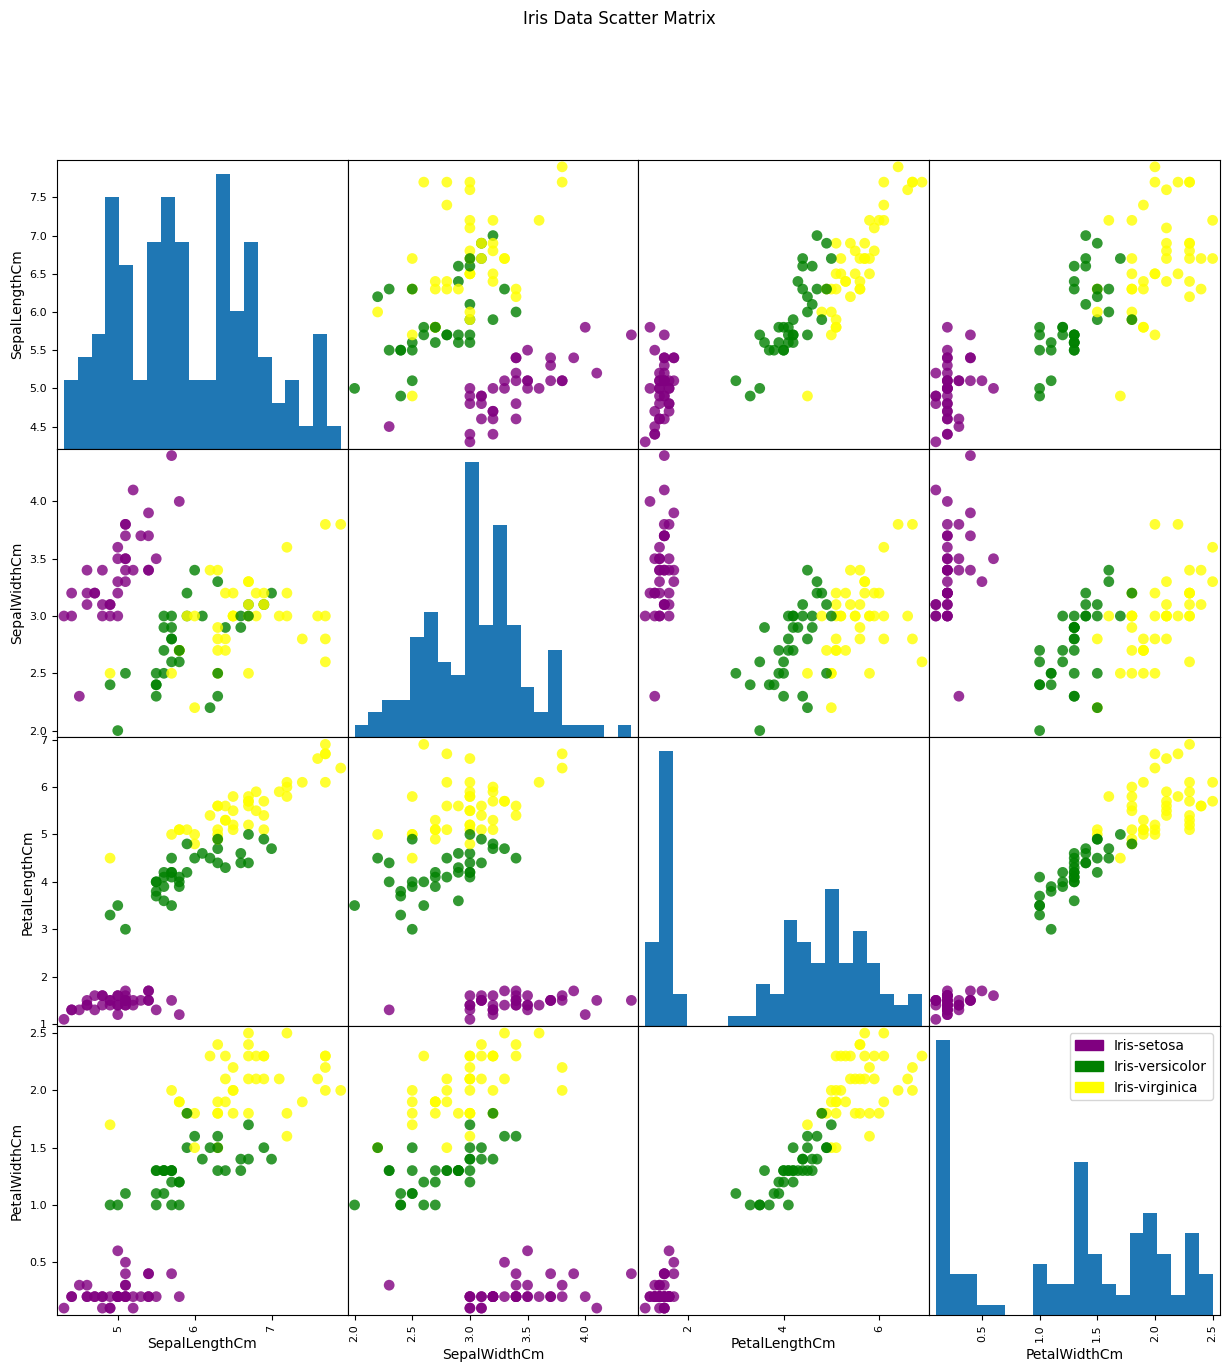

In [24]:
# create dataframe from data in X_train
# label the columns using the strings in iris_dataset.feature_names
print(X_train.columns)
print(iris_dataset.keys()[1:5])
iris_dataframe = pd.DataFrame(X_train, columns=iris_dataset.keys()[1:5])
# create a scatter matrix from the dataframe, color by y_train
# set static color for each species using dictionary, have in mind y_train is numpy array
colors = {0:'purple', 1:'green', 2:'yellow'}
color_values = [colors[label] for label in y_train]
pd.plotting.scatter_matrix(iris_dataframe, c=color_values, figsize=(15, 15),
                           marker='o', hist_kwds={'bins': 20}, s=60,
                           alpha=.8)

# add legend
import matplotlib.patches as mpatches
purple_patch = mpatches.Patch(color='purple', label=y[1][0])
green_patch = mpatches.Patch(color='green', label=y[1][1])
yellow_patch = mpatches.Patch(color='yellow', label=y[1][2])
plt.legend(handles=[purple_patch, green_patch, yellow_patch])
plt.suptitle('Iris Data Scatter Matrix')
plt.show()

# Building Your First Model: k-Nearest Neighbors

In [25]:
#Create learning object and model
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

In [26]:
#Train the model
knn.fit(X_train, y_train)

,n_neighbors,1
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# Make predictions / predictions

In [35]:
X_new = np.array([[5, 2.9, 1, 0.2]])
print("X_new.shape:", X_new.shape)

X_new.shape: (1, 4)


In [36]:
prediction = knn.predict(X_new)
print("Prediction:", prediction)
print("Predicted target name:", y[1][prediction])

Prediction: [0]
Predicted target name: Index(['Iris-setosa'], dtype='object')


c:\Users\USUARIO\personal\aprendizaje automatico\ml_env\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [39]:
prediction = knn.predict(X_test)
labels = y_test[prediction]

for i,val in enumerate(prediction):
    print("Predicted: {}. Actual: {} . Same: {}".format(prediction[i], labels[i], prediction[i] == labels[i]))

Predicted: 2. Actual: 0 . Same: False
Predicted: 1. Actual: 1 . Same: True
Predicted: 0. Actual: 2 . Same: False
Predicted: 2. Actual: 0 . Same: False
Predicted: 0. Actual: 2 . Same: False
Predicted: 2. Actual: 0 . Same: False
Predicted: 0. Actual: 2 . Same: False
Predicted: 1. Actual: 1 . Same: True
Predicted: 1. Actual: 1 . Same: True
Predicted: 1. Actual: 1 . Same: True
Predicted: 2. Actual: 0 . Same: False
Predicted: 1. Actual: 1 . Same: True
Predicted: 1. Actual: 1 . Same: True
Predicted: 1. Actual: 1 . Same: True
Predicted: 1. Actual: 1 . Same: True
Predicted: 0. Actual: 2 . Same: False
Predicted: 1. Actual: 1 . Same: True
Predicted: 1. Actual: 1 . Same: True
Predicted: 0. Actual: 2 . Same: False
Predicted: 0. Actual: 2 . Same: False
Predicted: 2. Actual: 0 . Same: False
Predicted: 1. Actual: 1 . Same: True
Predicted: 0. Actual: 2 . Same: False
Predicted: 0. Actual: 2 . Same: False
Predicted: 2. Actual: 0 . Same: False
Predicted: 0. Actual: 2 . Same: False
Predicted: 0. Actual: 2

# Evaluating the models:

In [40]:
y_pred = knn.predict(X_test)
print("Test set predictions:\n", y_pred)

Test set predictions:
 [2 1 0 2 0 2 0 1 1 1 2 1 1 1 1 0 1 1 0 0 2 1 0 0 2 0 0 1 1 0 2 1 0 2 2 1 0
 2]


In [41]:
print("Test set score: {:.2f}".format(np.mean(y_pred == y_test)))

Test set score: 0.97


In [42]:
print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 0.97


### Summary and Outlook

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    iris_dataset.loc[:,'SepalLengthCm':'PetalWidthCm'], y[0], random_state=0)
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train, y_train)

print("Test set score: {:.2f}".format(knn.score(X_test, y_test)))

Test set score: 0.97
